<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_77_imbalanced_data_yt/Lecture_77_imbalanced_data_yt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [11]:
# set random seed for reproducibility
np.random.seed(42)


In [12]:
# Generate imbalanced dataset
n_samples_1 = 25
n_samples_2 = 375
center = [(0,0), (2,2)]
cluster_std = [1.5,1.5]

In [13]:
X, y = make_blobs(n_samples=[n_samples_1, n_samples_2], centers=center, cluster_std=cluster_std, random_state=0)



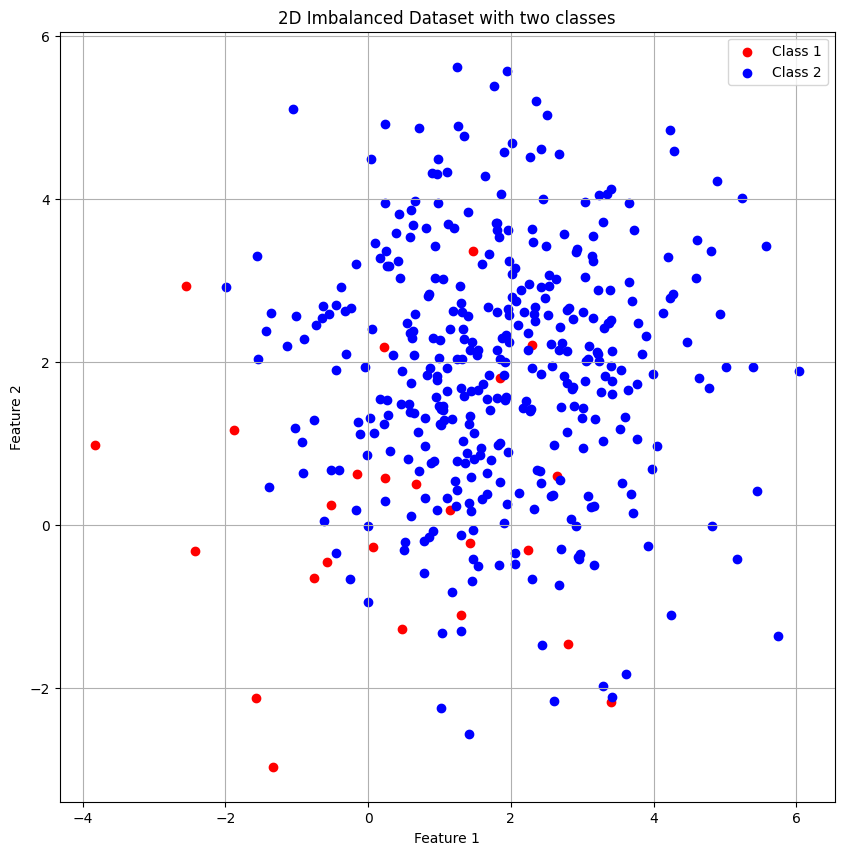

In [14]:
# plotting
plt.figure(figsize=(10,10))
plt.scatter(X[y == 0][:, 0],X[y == 0][:,1], color='red', label='Class 1')
plt.scatter(X[y == 1][:, 0],X[y == 1][:,1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [16]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
# Initialize and train RandomForest classifier
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [18]:
# predict test set
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

In [19]:
# Print classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.96      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.98      0.64      0.71       120
weighted avg       0.96      0.96      0.95       120



In [20]:
# print ROC AUC Score
print('ROC AUC Score:', roc_auc_score(y_test, y_proba))

ROC AUC Score: 0.9557522123893806


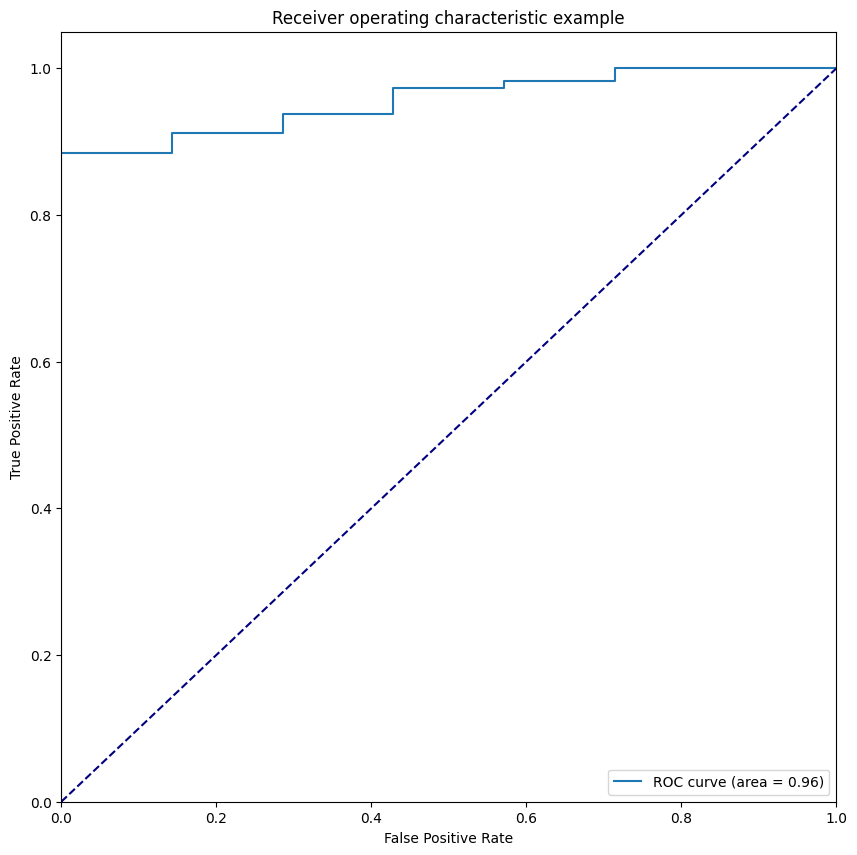

In [21]:
# plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(10,10))
plt.plot(fpr, tpr, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [22]:
# Function to plot decision boundaries
def plot_decision_boundary(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary')
  plt.show()


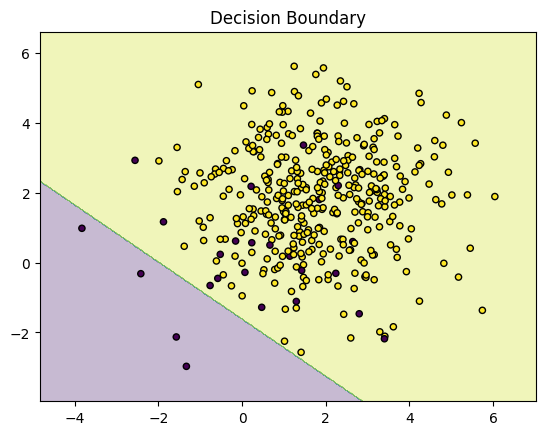

In [23]:
# plot decision boundary
plot_decision_boundary(X, y, classifier)

# Random Undersampling

In [24]:
from imblearn.under_sampling import RandomUnderSampler

In [25]:
# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Applying Random Over Sampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

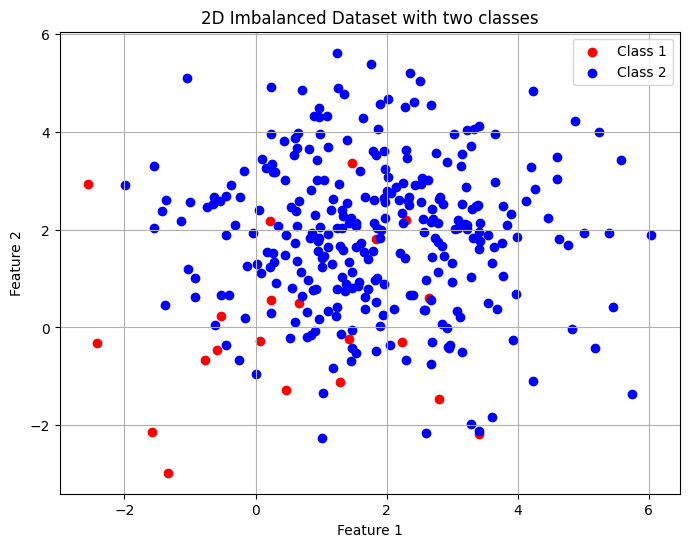

In [27]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],color='red', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

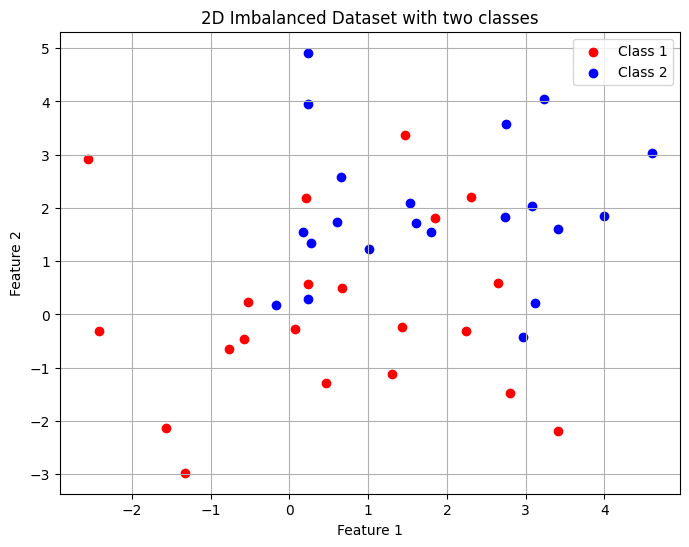

In [28]:
# plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled[y_resampled == 0][:, 0], X_resampled[y_resampled == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled[y_resampled == 1][:, 0], X_resampled[y_resampled == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
X_train.shape

(320, 2)

In [30]:
X_resampled.shape

(42, 2)

In [31]:
import pandas as pd

pd.Series(y_train).value_counts()

,count
1,299
0,21


In [32]:
pd.Series(y_resampled).value_counts()

,count
0,21
1,21


In [33]:
from sklearn.linear_model import LogisticRegression

classifier_rus = LogisticRegression()
classifier_rus.fit(X_resampled, y_resampled)


LogisticRegression()

In [34]:
# Predict test set

y_pred_rus = classifier_rus.predict(X_test)
y_proba_rus = classifier_rus.predict_proba(X_test)[:, 1]

In [35]:
# print classification report for resampled data

print('Classification Report (with Over Sampling):')
print(classification_report(y_test, y_pred_rus))

Classification Report (with Over Sampling):
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80



In [36]:
# print ROC Score for resampled data
print('ROC AUC Score (with Over Sampling):', roc_auc_score(y_test, y_proba_rus))

ROC AUC Score (with Over Sampling): 0.9375


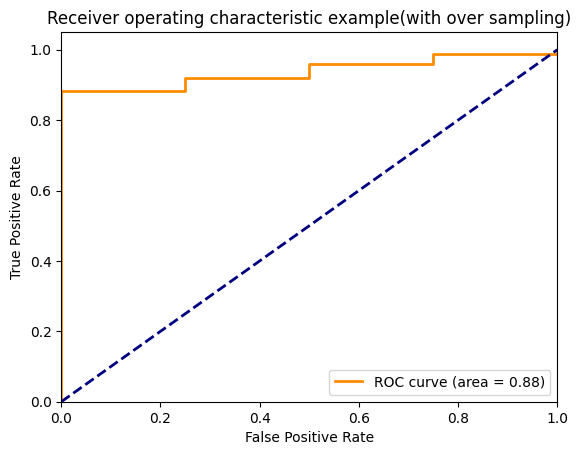

In [37]:
# Plotting ROC AUC Curve for resampled data
fpr_rus, tpr_rus, _ = roc_curve(y_test, y_proba_rus)
plt.figure()
plt.plot(fpr_rus, tpr_rus, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_rus))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example(with over sampling)')
plt.legend(loc="lower right")
plt.show()

In [38]:
# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary (with Over Sampling)')
  plt.show()


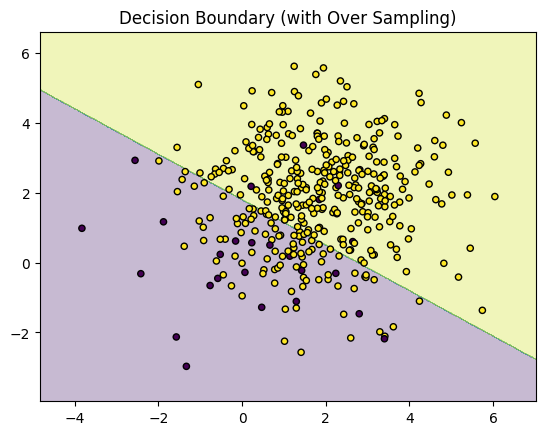

In [39]:
# plot decision boundary for resampled data
plot_decision_boundaries_ros(X, y, classifier_rus)

## SMOTE

In [40]:
from imblearn.over_sampling import SMOTE

In [41]:
# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# Applying SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)


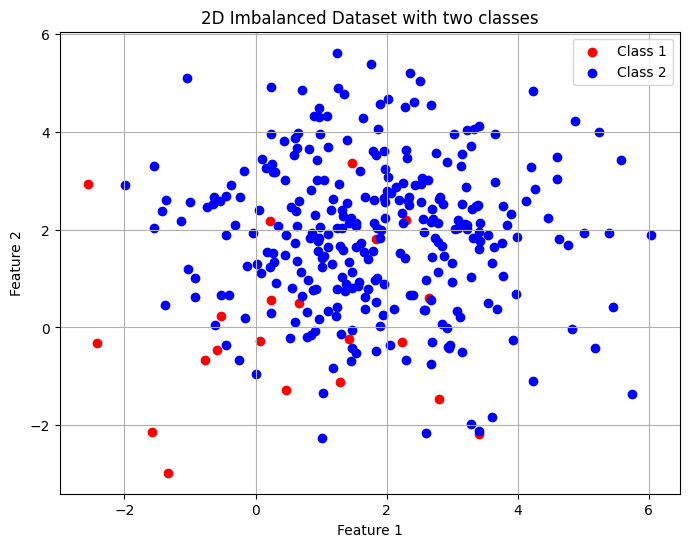

In [43]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],color='red', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

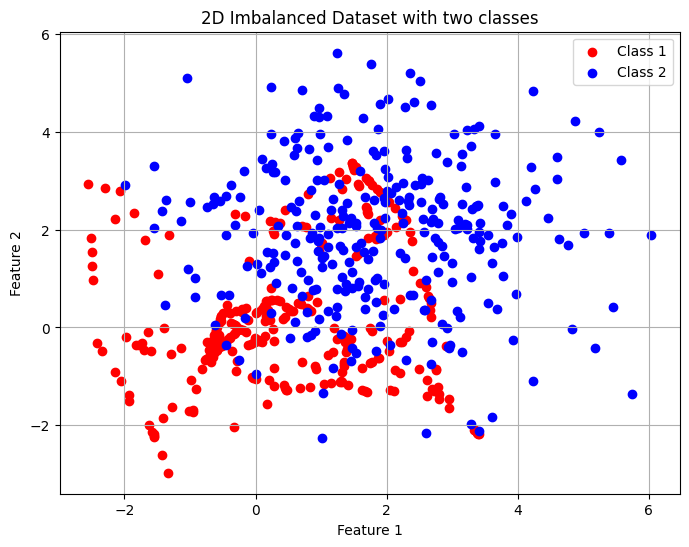

In [44]:
# plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled_smote[y_resampled_smote == 0][:, 0], X_resampled_smote[y_resampled_smote == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled_smote[y_resampled_smote == 1][:, 0], X_resampled_smote[y_resampled_smote == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
X_train.shape

(320, 2)

In [46]:
X_resampled_smote.shape

(598, 2)

In [47]:
pd.Series(y_train).value_counts()

,count
1,299
0,21


In [48]:
pd.Series(y_resampled_smote).value_counts()

,count
1,299
0,299


In [49]:
# initialize and train RandomForest classifier on resampled data
classifier_smote = LogisticRegression()
classifier_smote.fit(X_resampled_smote, y_resampled_smote)

LogisticRegression()

In [50]:
# predict test set
y_pred_smote = classifier_smote.predict(X_test)
y_proba_smote = classifier_smote.predict_proba(X_test)[:, 1]


In [51]:
# print classification report for SMOTE data
print('Classification Report (with SMOTE):')
print(classification_report(y_test, y_pred_smote))

Classification Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.17      1.00      0.30         4
           1       1.00      0.75      0.86        76

    accuracy                           0.76        80
   macro avg       0.59      0.88      0.58        80
weighted avg       0.96      0.76      0.83        80



In [52]:
# print ROC AUC Score for SMOTE data
print('ROC AUC Score (with SMOTE):', roc_auc_score(y_test, y_proba_smote))

ROC AUC Score (with SMOTE): 0.950657894736842


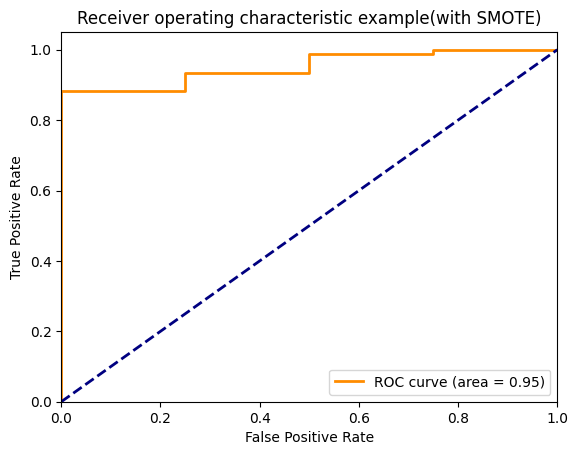

In [53]:
# plotting ROC AUC Curve for SMOTE data
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)
plt.figure()
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_smote))

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example(with SMOTE)')
plt.legend(loc="lower right")
plt.show()

In [54]:
# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary (with SMOTE)')
  plt.show()

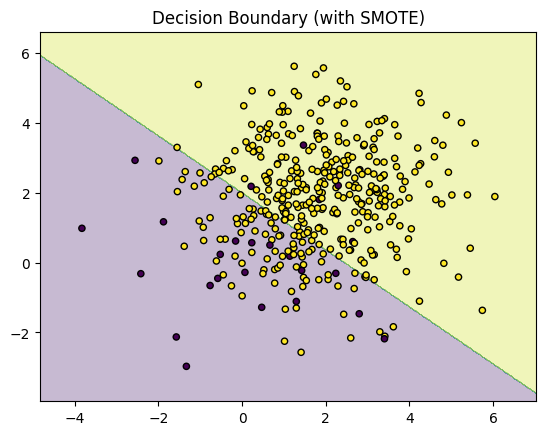

In [55]:
# plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, classifier_smote)